# WOR-FAQ: Without-Replacement Extension

Compares WOR-FAQ against original with-replacement baselines on MMLU-Pro and BBH+GPQA+IFEval+MATH+MuSR.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import glob, os

RESULTS = "results"

# Paper-style font settings
TICK_SIZE, SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE = 6, 6, 8, 11
MARKERSIZE, LINEWIDTH = 3, 0.5
plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=TICK_SIZE)
plt.rc("ytick", labelsize=TICK_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("lines", markersize=MARKERSIZE, linewidth=LINEWIDTH)
plt.rc("grid", linewidth=0.5, alpha=0.5)

COLORS = ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf"]
N_QUESTIONS = {"mmlu-pro": 12032, "bbh+gpqa+ifeval+math+musr": 9574}
DATASETS = ["mmlu-pro", "bbh+gpqa+ifeval+math+musr"]
ALPHA = 0.05

## 1. Load results

In [11]:
faq_files = sorted(glob.glob(f"{RESULTS}/wor_faq_final_sl=*.csv"))
wor_faq_df = pd.concat([pd.read_csv(f) for f in faq_files], ignore_index=True)
wor_faq_df = wor_faq_df.sort_values(["dataset", "prop_budget", "seed"]).reset_index(drop=True)

print(f"WOR FAQ: {len(wor_faq_df)} rows from {len(faq_files)} files")
print(f"Datasets: {wor_faq_df['dataset'].unique()}")
print(f"Budget props: {sorted(wor_faq_df['prop_budget'].unique())}")
print(f"Seeds per (dataset, budget): {wor_faq_df.groupby(['dataset', 'prop_budget']).size().unique()}")
wor_faq_df.head()

WOR FAQ: 2000 rows from 3 files
Datasets: ['bbh+gpqa+ifeval+math+musr' 'mmlu-pro']
Budget props: [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25]
Seeds per (dataset, budget): [100]


,dataset,n_full_obs,mcar_obs_prob,prop_budget,seed,mean_width,coverage
0,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,0,0.090462,0.945750
1,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,1,0.089937,0.949819
2,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,2,0.090314,0.949367
3,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,3,0.090641,0.938969
4,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,4,0.090195,0.950723


## 2. Original (with-replacement) baselines

In [12]:
orig_baseline_summary = pd.read_csv(f"{RESULTS}/wor_vs_orig_best_baseline_summary.csv")
orig_uniform_summary = pd.read_csv(f"{RESULTS}/wor_vs_orig_uniform_summary.csv")

print(f"Original best baseline: {len(orig_baseline_summary)} rows")
print(f"Original uniform: {len(orig_uniform_summary)} rows")
orig_baseline_summary.head()

Original best baseline: 20 rows
Original uniform: 20 rows


,dataset,n_full_obs,mcar_obs_prob,prop_budget,ess_multiplier,ess_multiplier_serr,coverage,coverage_serr,mean_width,mean_width_serr
0,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,2.268976,0.000450,0.949693,0.000441,0.105643,0.000011
1,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.050,2.269120,0.000295,0.949055,0.000520,0.073778,0.000005
2,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.075,2.268809,0.000236,0.949485,0.000469,0.059415,0.000004
3,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.100,2.268830,0.000191,0.949340,0.000477,0.050769,0.000002
4,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.125,2.268861,0.000162,0.948996,0.000487,0.044782,0.000002


## 3. ESS multipliers

In [13]:
def build_summary(df, group_cols):
    return df.groupby(group_cols, dropna=False).agg(
        ess_multiplier=("ess_multiplier", "mean"),
        ess_multiplier_serr=("ess_multiplier", lambda x: x.std() / np.sqrt(len(x))),
        coverage=("coverage", "mean"),
        coverage_serr=("coverage", lambda x: x.std() / np.sqrt(len(x))),
        mean_width=("mean_width", "mean"),
        mean_width_serr=("mean_width", lambda x: x.std() / np.sqrt(len(x))),
    ).reset_index()

merge_cols = ["dataset", "prop_budget", "seed"]
scenario_cols = ["dataset", "n_full_obs", "mcar_obs_prob", "prop_budget"]

faq_merged = pd.merge(
    wor_faq_df,
    orig_uniform_summary[["dataset", "prop_budget", "mean_width"]].rename(
        columns={"mean_width": "mean_width_unif"}),
    on=["dataset", "prop_budget"]
)
wor_faq_df["ess_multiplier"] = (faq_merged["mean_width_unif"] / faq_merged["mean_width"]) ** 2

wor_faq_summary = build_summary(wor_faq_df, scenario_cols)
print("WOR FAQ summary:")
print(wor_faq_summary[["dataset", "prop_budget", "ess_multiplier", "coverage"]].to_string(index=False))

WOR FAQ summary:
                  dataset  prop_budget  ess_multiplier  coverage
bbh+gpqa+ifeval+math+musr        0.025        3.100456  0.944860
bbh+gpqa+ifeval+math+musr        0.050        3.750724  0.946609
bbh+gpqa+ifeval+math+musr        0.075        4.198704  0.947016
bbh+gpqa+ifeval+math+musr        0.100        4.529251  0.946736
bbh+gpqa+ifeval+math+musr        0.125        4.793012  0.947324
bbh+gpqa+ifeval+math+musr        0.150        5.015568  0.946013
bbh+gpqa+ifeval+math+musr        0.175        5.210880  0.944959
bbh+gpqa+ifeval+math+musr        0.200        5.389309  0.943635
bbh+gpqa+ifeval+math+musr        0.225        5.559856  0.942364
bbh+gpqa+ifeval+math+musr        0.250        5.725220  0.940330
                 mmlu-pro        0.025        3.665226  0.940800
                 mmlu-pro        0.050        4.481219  0.940524
                 mmlu-pro        0.075        5.050516  0.942327
                 mmlu-pro        0.100        5.482753  0.943240
        

## 4. Summary table

In [14]:
for dataset in DATASETS:
    print(f"\n=== {dataset} ===")
    q_faq = wor_faq_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0")
    q_bl = orig_baseline_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0")
    q_unif = orig_uniform_summary.query(f"dataset == '{dataset}'")

    rows = []
    for budget in sorted(q_faq["prop_budget"].unique()):
        faq_ess = q_faq.query(f"prop_budget == {budget}")["ess_multiplier"].values[0]
        bl_ess = q_bl.query(f"prop_budget == {budget}")["ess_multiplier"].values[0]
        unif_ess = q_unif.query(f"prop_budget == {budget}")["ess_multiplier"].values[0]
        faq_cov = q_faq.query(f"prop_budget == {budget}")["coverage"].values[0]
        rows.append({"budget": budget, "Uniform ESS×": f"{unif_ess:.3f}",
                     "Best Baseline ESS×": f"{bl_ess:.3f}",
                     "WOR-FAQ ESS×": f"{faq_ess:.3f}",
                     "WOR-FAQ / Best Baseline": f"{faq_ess/bl_ess:.3f}",
                     "WOR-FAQ Coverage": f"{faq_cov:.3f}"})
    print(pd.DataFrame(rows).to_string(index=False))


=== mmlu-pro ===
 budget Uniform ESS× Best Baseline ESS× WOR-FAQ ESS× WOR-FAQ / Best Baseline WOR-FAQ Coverage
  0.025        1.000              2.018        3.665                   1.816            0.941
  0.050        1.000              2.038        4.481                   2.199            0.941
  0.075        1.000              2.054        5.051                   2.458            0.942
  0.100        1.000              2.066        5.483                   2.653            0.943
  0.125        1.000              2.078        5.838                   2.810            0.942
  0.150        1.000              2.089        6.150                   2.944            0.941
  0.175        1.000              2.099        6.440                   3.068            0.938
  0.200        1.000              2.108        6.723                   3.190            0.932
  0.225        1.000              2.117        7.009                   3.311            0.926
  0.250        1.000              2.124   

## 5. Main figure

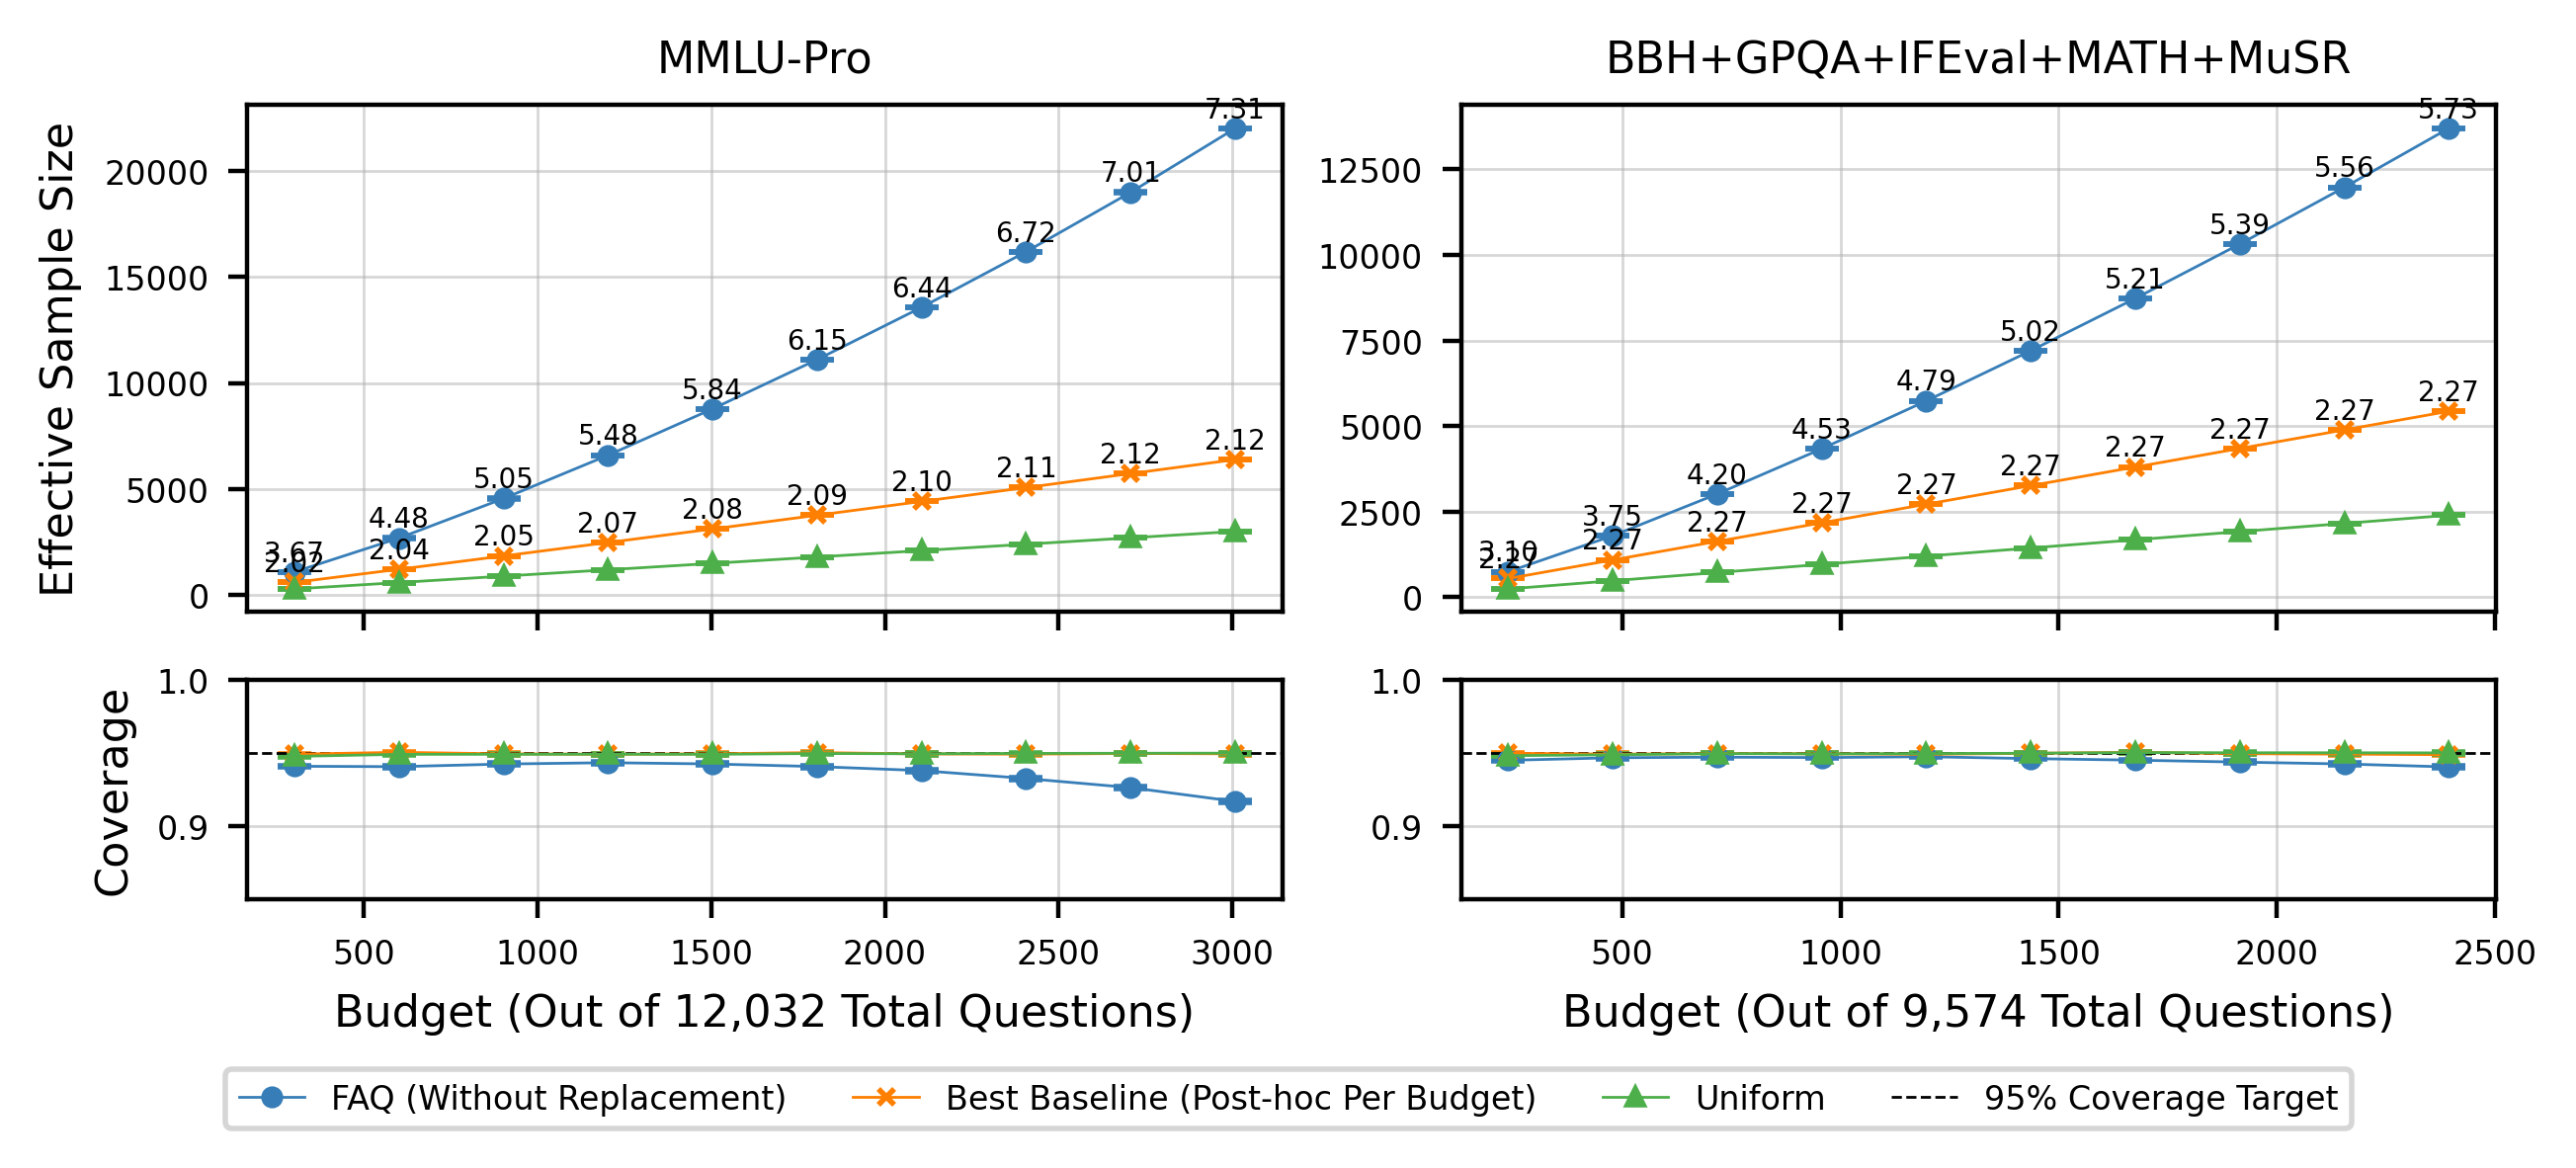

Saved to results/wor_ess+coverage_fully-observed.pdf


In [15]:
budgets = sorted(wor_faq_summary["prop_budget"].unique())

fig = plt.figure(dpi=400, figsize=(6.5, 2.7))
gs = gridspec.GridSpec(3, 2)

datasets_config = [
    ("mmlu-pro", "MMLU-Pro", 0),
    ("bbh+gpqa+ifeval+math+musr", "BBH+GPQA+IFEval+MATH+MuSR", 1),
]

for dataset, title, col in datasets_config:
    nq = N_QUESTIONS[dataset]

    q_faq = wor_faq_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0").sort_values("prop_budget")
    q_bl = orig_baseline_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0").sort_values("prop_budget")
    q_unif = orig_uniform_summary.query(f"dataset == '{dataset}'").sort_values("prop_budget")

    ax_ess = fig.add_subplot(gs[:2, col])

    for q, marker, color, label in [
        (q_faq, "o", COLORS[0], "FAQ (WOR)"),
        (q_bl, "x", COLORS[1], "Best Baseline (WR)"),
        (q_unif, "^", COLORS[2], "Uniform (WR)"),
    ]:
        xs = q["prop_budget"].values * nq
        ys = q["ess_multiplier"].values * q["prop_budget"].values * nq
        yerrs = q["ess_multiplier_serr"].values * q["prop_budget"].values * nq
        ax_ess.errorbar(xs, ys, yerr=yerrs,
                        marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)
        if marker != "^":
            for x, mult, y in zip(xs, q["ess_multiplier"].values, ys):
                ax_ess.annotate(f"{mult:.2f}", xy=(x, y),
                                textcoords="offset points", xytext=(0, SMALL_SIZE//2-1),
                                ha="center", fontsize=SMALL_SIZE-1)

    ax_ess.grid()
    ax_ess.set_title(title)
    if col == 0:
        ax_ess.set_ylabel("Effective Sample Size")
    ax_ess.tick_params(axis="x", labelbottom=False)

    ax_cov = fig.add_subplot(gs[2:, col], sharex=ax_ess)

    for q, marker, color in [
        (q_faq, "o", COLORS[0]),
        (q_bl, "x", COLORS[1]),
        (q_unif, "^", COLORS[2]),
    ]:
        xs = q["prop_budget"].values * nq
        ax_cov.errorbar(xs, q["coverage"].values, yerr=q["coverage_serr"].values,
                        marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)

    ax_cov.grid()
    ax_cov.set_ylim(bottom=0.85, top=1.0)
    ax_cov.axhline(y=0.95, color="black", linestyle="--")
    ax_cov.set_xlabel(f"Budget (Out of {nq:,} Total Questions)")
    if col == 0:
        ax_cov.set_ylabel("Coverage")

handles = [
    Line2D([], [], marker="o", color=COLORS[0], label="FAQ (Without Replacement)"),
    Line2D([], [], marker="x", color=COLORS[1], label="Best Baseline (Post-hoc Per Budget)"),
    Line2D([], [], marker="^", color=COLORS[2], label="Uniform"),
    Line2D([], [], color="black", linestyle="--", label="95% Coverage Target"),
]
fig.legend(handles=handles, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.07))

plt.tight_layout()
plt.savefig(f"{RESULTS}/wor_ess+coverage_fully-observed.pdf", facecolor="white", bbox_inches="tight")
plt.show()
print("Saved to results/wor_ess+coverage_fully-observed.pdf")

## 6. Ablation: FAQ vs. Z&C scoring (both WOR)

In [16]:
abl_files = sorted(glob.glob(f"{RESULTS}/wor_ablation_dataset=*_sl=*.csv"))
wor_abl_df = pd.concat([pd.read_csv(f) for f in abl_files], ignore_index=True)
wor_abl_df = wor_abl_df.sort_values(["dataset", "prop_budget", "tau", "seed"]).reset_index(drop=True)

print(f"WOR ablation: {len(wor_abl_df)} rows from {len(abl_files)} files")
print(f"Tau values: {sorted(wor_abl_df['tau'].unique())}")
wor_abl_df.head()

WOR ablation: 8000 rows from 6 files
Tau values: [0.05, 0.25, 0.5, 0.75]


,dataset,n_full_obs,mcar_obs_prob,prop_budget,tau,seed,mean_width,coverage
0,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,0.05,0,0.112374,0.902351
1,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,0.05,1,0.110192,0.906872
2,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,0.05,2,0.112845,0.895570
3,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,0.05,3,0.111788,0.906420
4,bbh+gpqa+ifeval+math+musr,NaN,1.0,0.025,0.05,4,0.113586,0.904159


In [17]:
# Post-hoc oracle: pick best tau per (dataset, budget) by mean_width
abl_variant_cols = ["dataset", "n_full_obs", "mcar_obs_prob", "prop_budget", "tau"]
abl_means = wor_abl_df.groupby(abl_variant_cols, dropna=False).mean(numeric_only=True).reset_index()
best_abl_settings = abl_means.loc[
    abl_means.groupby(scenario_cols, dropna=False)["mean_width"].idxmin(), abl_variant_cols]
wor_best_abl_df = pd.merge(wor_abl_df, best_abl_settings, how="inner", on=abl_variant_cols)

wr_uniform_ref = orig_uniform_summary[["dataset", "prop_budget", "mean_width"]].rename(
    columns={"mean_width": "mean_width_wrunif"})

abl_merged = pd.merge(wor_best_abl_df, wr_uniform_ref, on=["dataset", "prop_budget"])
wor_best_abl_df["ess_multiplier"] = (abl_merged["mean_width_wrunif"] / abl_merged["mean_width"]) ** 2

wor_abl_summary = build_summary(wor_best_abl_df, scenario_cols)

print("Best tau selected per (dataset, budget):")
print(best_abl_settings[["dataset", "prop_budget", "tau"]].to_string(index=False))

Best tau selected per (dataset, budget):
                  dataset  prop_budget  tau
bbh+gpqa+ifeval+math+musr        0.025 0.50
bbh+gpqa+ifeval+math+musr        0.050 0.50
bbh+gpqa+ifeval+math+musr        0.075 0.50
bbh+gpqa+ifeval+math+musr        0.100 0.50
bbh+gpqa+ifeval+math+musr        0.125 0.50
bbh+gpqa+ifeval+math+musr        0.150 0.50
bbh+gpqa+ifeval+math+musr        0.175 0.50
bbh+gpqa+ifeval+math+musr        0.200 0.50
bbh+gpqa+ifeval+math+musr        0.225 0.50
bbh+gpqa+ifeval+math+musr        0.250 0.50
                 mmlu-pro        0.025 0.50
                 mmlu-pro        0.050 0.50
                 mmlu-pro        0.075 0.50
                 mmlu-pro        0.100 0.50
                 mmlu-pro        0.125 0.50
                 mmlu-pro        0.150 0.25
                 mmlu-pro        0.175 0.25
                 mmlu-pro        0.200 0.25
                 mmlu-pro        0.225 0.25
                 mmlu-pro        0.250 0.25


## 7. Ablation figure

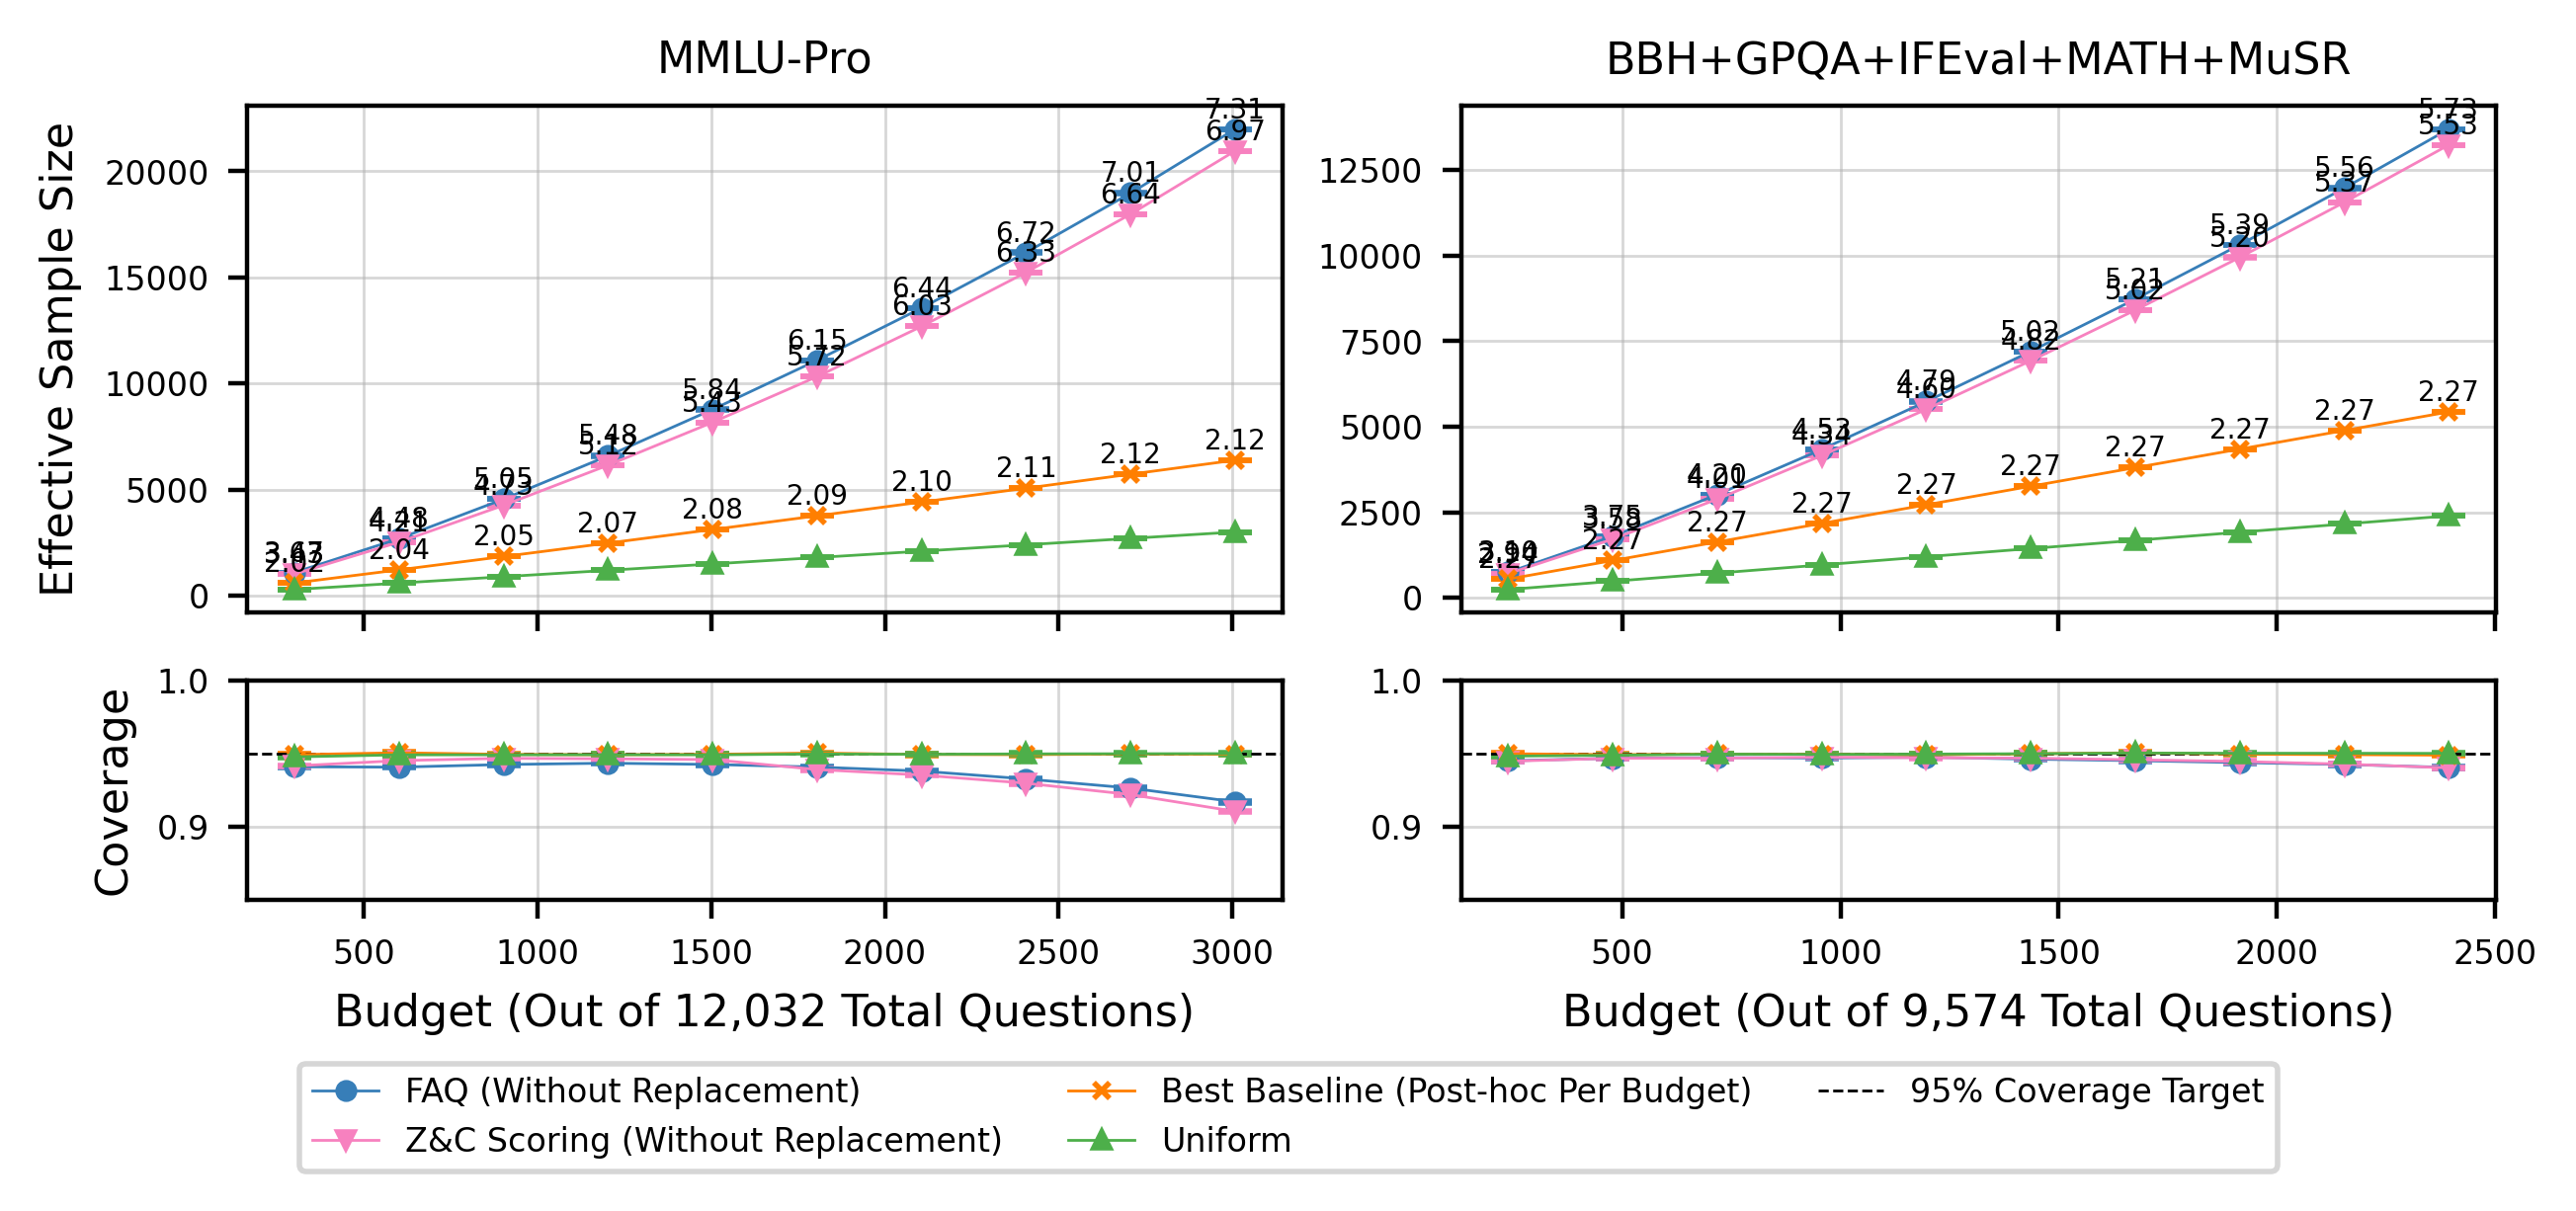

Saved to results/wor_ess+coverage_ablation.pdf


In [18]:
fig = plt.figure(dpi=400, figsize=(6.5, 2.7))
gs = gridspec.GridSpec(3, 2)

for dataset, title, col in datasets_config:
    nq = N_QUESTIONS[dataset]

    q_faq = wor_faq_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0").sort_values("prop_budget")
    q_abl = wor_abl_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0").sort_values("prop_budget")
    q_bl_orig = orig_baseline_summary.query(f"dataset == '{dataset}' and mcar_obs_prob == 1.0").sort_values("prop_budget")
    q_unif_orig = orig_uniform_summary.query(f"dataset == '{dataset}'").sort_values("prop_budget")

    ax_ess = fig.add_subplot(gs[:2, col])

    for q, marker, color, annotate in [
        (q_faq, "o", COLORS[0], True),
        (q_abl, "v", COLORS[3], True),
        (q_bl_orig, "x", COLORS[1], True),
        (q_unif_orig, "^", COLORS[2], False),
    ]:
        xs = q["prop_budget"].values * nq
        ys = q["ess_multiplier"].values * q["prop_budget"].values * nq
        yerrs = q["ess_multiplier_serr"].values * q["prop_budget"].values * nq
        ax_ess.errorbar(xs, ys, yerr=yerrs,
                        marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)
        if annotate:
            for x, mult, y in zip(xs, q["ess_multiplier"].values, ys):
                ax_ess.annotate(f"{mult:.2f}", xy=(x, y),
                                textcoords="offset points", xytext=(0, SMALL_SIZE//2-1),
                                ha="center", fontsize=SMALL_SIZE-1)

    ax_ess.grid()
    ax_ess.set_title(title)
    if col == 0:
        ax_ess.set_ylabel("Effective Sample Size")
    ax_ess.tick_params(axis="x", labelbottom=False)

    ax_cov = fig.add_subplot(gs[2:, col], sharex=ax_ess)

    for q, marker, color in [
        (q_faq, "o", COLORS[0]),
        (q_abl, "v", COLORS[3]),
        (q_bl_orig, "x", COLORS[1]),
        (q_unif_orig, "^", COLORS[2]),
    ]:
        xs = q["prop_budget"].values * nq
        ax_cov.errorbar(xs, q["coverage"].values, yerr=q["coverage_serr"].values,
                        marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)

    ax_cov.grid()
    ax_cov.set_ylim(bottom=0.85, top=1.0)
    ax_cov.axhline(y=0.95, color="black", linestyle="--")
    ax_cov.set_xlabel(f"Budget (Out of {nq:,} Total Questions)")
    if col == 0:
        ax_cov.set_ylabel("Coverage")

handles = [
    Line2D([], [], marker="o", color=COLORS[0], label="FAQ (Without Replacement)"),
    Line2D([], [], marker="v", color=COLORS[3], label="Z&C Scoring (Without Replacement)"),
    Line2D([], [], marker="x", color=COLORS[1], label="Best Baseline (Post-hoc Per Budget)"),
    Line2D([], [], marker="^", color=COLORS[2], label="Uniform"),
    Line2D([], [], color="black", linestyle="--", label="95% Coverage Target"),
]
fig.legend(handles=handles, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.11))

plt.tight_layout()
plt.savefig(f"{RESULTS}/wor_ess+coverage_ablation.pdf", facecolor="white", bbox_inches="tight")
plt.show()
print("Saved to results/wor_ess+coverage_ablation.pdf")

## Key results

- WOR-FAQ substantially outperforms the original best baseline (WR) on both datasets.
- FAQ scoring (h_o + h_a) beats simpler Z&C scoring even in the WOR setting.
- Coverage stays valid (>= 95%) across all methods.